# H38: giới hạn bất đồng cao độ và kiểm chứng từ WAV

F0 là tần số cơ bản; V/UV/SIL là hữu thanh, vô thanh và khoảng lặng. Praat filtered .30 quyết định V/UV và làm nguồn cao độ neo. REAPER .9 là nguồn cao độ thứ hai. H38 chỉ dùng REAPER khi nó hợp lệ gần cùng thời điểm và lệch với Praat không quá100 hoặc200cents. 1200cents là một octave, tương ứng tần số gấp đôi;100cents là một bán âm. Ngoài band hoặc thiếu REAPER, giữ Praat.

Alpha1 dùng nguyên REAPER; alpha.5 dùng trung bình hình học sqrt(Praat×REAPER). Hai tham số band/alpha được chọn trong inner folds, không dùng file đang chấm. Grid có sáu options: control Praat, REAPER dưới cổng Praat không giới hạn (ablation H37), và bốn kết hợp. Không sửa octave, xóa/thêm khung, sửa theo ground truth hay lựa chọn theo tên/giới/device.

Average MAPE là trung bình lỗi phần trăm của F0mean, F0std (ddof0) và F0num. Mục tiêu **mỗi file≤2%**; một mean nhỏ chưa đủ. LAB chứa thống kê cảfile và nhãn đoạn, không F0 chuẩn từng khung. Hai nguồn đồng thuận chưa chứng minh đúng. Notebook tính lại tất cả options đã đăng ký và nested choices đã lưu; không mở grid mới. Có control AMDF H24 để đối chiếu.


In [1]:
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
REPO=Path('C:\\Users\\LAPTOP T&T\\VIOLETTA\\Documents\\ChatGPT\\XLTN\\XLTN-BT2')
HERE=REPO/'research_workbench_2026_10_07'
sys.path.insert(0,str(HERE))
import amdf_dual_window as dual
import reaper_praat_bounded as reaper
import reaper_praat_bounded as hybrid
core,audit=dual.core,dual.audit
items=core.load_training()
by_name={x['file']:x for x in items}
config=json.loads((core.RESULTS/'frozen_config.json').read_text())['models']['AMDF_energy']['config']
families={'H38':hybrid}
receipts={f:json.loads((HERE/f'results/{f}_experiment.json').read_text()) for f in families}
for receipt in receipts.values():
    for relative,expected in receipt['code_sha256'].items():
        assert audit.digest(REPO/relative)==expected,relative
    for file,expected in receipt['data_sha256'].items():
        assert audit.digest(core.TRAIN/file)==expected,file
native_proof=reaper.native_api.metadata()
sptk_proof=reaper.sptk_api.metadata()
hybrid.SOURCE_CACHE.clear()
print('Local Python:',sys.executable,'; Praat',native_proof['version_stdout'],'; SPTK',sptk_proof['version'])
print('Chỉ train WAV, không đọc test. Ground truth là file-stat và nhãn đoạn.')
display(pd.DataFrame([{'file':x['file'],'fs':x['fs'],**x['stats'],'segment_V_frames':int((x['labels']=='v').sum())} for x in items]))


Local Python: C:\Users\violet\miniconda3\python.exe ; Praat 7.0.02 ; SPTK 4.4
Chỉ train WAV, không đọc test. Ground truth là file-stat và nhãn đoạn.


file,fs,F0mean,F0std,F0num,segment_V_frames
phone_F1.wav,16000,215.6,20.6,148.0,153
phone_M1.wav,16000,123.7,16.8,232.0,244
studio_F1.wav,44100,229.6,36.8,127.0,123
studio_M1.wav,44100,116.9,26.4,82.0,94


## Tái lập fixed từ WAV

Fixed nghĩa là chấm một cấu hình đã chốt trên cả bốn file; không chọn cấu hình riêng theo chính file đang chấm. H24 fit cổng AMDF bằng ba file còn lại. Praat/REAPER không fit bằng nhãn; các file khác chỉ được dùng khi chọn option ở nested.

REAPER input float64 khôi phục scale PCM16 bằng ×32768, output Hz với UV=0, mốc thời gian 0. H38 ghép REAPER vào lưới Praat trước, rồi ghép Praat vào lưới chấm 25/10 ms. Ghép tâm gần nhất trong nửa hop cộng một mẫu; nếu hòa chọn sớm. Không thêm padding, interpolation hay smoothing của agent. Internal padding của mã REAPER vẫn giữ theo implementation.


In [2]:
registries={f:json.loads((HERE/f'{f}_REGISTRY.json').read_text())['options'] for f in families}
features={}
native_calls={}
rows,contour_rows,fit_logs=[],[],[]
columns=['F0mean','F0std','F0num','F0mean_mape','F0std_mape','F0num_mape','average_mape',
         'macro_f1','recall_v','recall_uv','balanced_accuracy','TP','FN','FP','TN','false_voiced_sil']

def feature(module,option,item):
    key=(module.__name__,module.feature_key(option),item['file'])
    if key not in features:
        _,audio=core.load_audio(core.TRAIN/item['file'])
        features[key]=module.extract(item,audio,option)
        if 'native_call' in features[key]:
            native_calls['|'.join(key)]=features[key]['native_call']
    return features[key]

def measure(family,module,option,held,split):
    pool=[x for x in items if x['file']!=held['file']]
    native=feature(module,option,held)
    training=[feature(module,option,x) for x in pool]
    pred,f0,fit,_=module.infer(native,training,option,config)
    if module is dual:
        fit=dict(fit,requires_fit=True,actual_fit_files=sorted(x['file'] for x in pool))
    pred,f0,support=module.project(native,held,pred,f0,option['hop_ms'])
    measured=core.score_file(held,pred,f0)
    saved=pd.read_csv(HERE/f'results/{family}_fixed_lofo.csv') if split=='fixed' else pd.read_csv(HERE/f'results/{family}_metrics.csv')
    saved=saved[(saved.option_id==option['id'])&(saved.file==held['file'])]
    if split=='nested':
        saved=saved[(saved.split=='nested')&(saved.model=='candidate')]
    assert len(saved)==1
    assert np.allclose([measured[k] for k in columns],saved.iloc[0][columns].astype(float),atol=1e-8),(family,option['id'],held['file'])
    method=option['id'] if split=='fixed' else family+'_nested'
    rows.append({'evaluation':split,'method':method,'family':family,'option_id':option['id'],**measured})
    fit_logs.append({'evaluation':split,'method':method,'held_file':held['file'],'fit_files':sorted(x['file'] for x in pool),'fitted':fit})
    contour_rows.extend({'evaluation':split,'method':method,'family':family,'file':held['file'],
                        'time_s':float(t),'label':str(lab),'pred_voiced':bool(p),'f0_hz':float(f),'support':bool(s)}
                       for t,lab,p,f,s in zip(held['times'],held['labels'],pred,f0,support))

for held in items:
    measure('H24',dual,dual.registry('H24')[1],held,'fixed')
for family,module in families.items():
    for option in registries[family]:
        for held in items:
            measure(family,module,option,held,'fixed')
display(pd.DataFrame(rows)[['family','option_id','file','average_mape','F0mean_mape','F0std_mape','F0num_mape','false_voiced_sil']])
print('PASS28 fixed rows được tính từ WAV, khớp số liệu đã lưu 1e-8.')


PASS28 fixed rows được tính từ WAV, khớp số liệu đã lưu 1e-8.


family,option_id,file,average_mape,F0mean_mape,F0std_mape,F0num_mape,false_voiced_sil
H24,amdf_gate25_pitch40,phone_F1.wav,8.899895,1.007605,22.313703,3.378378,1
H24,amdf_gate25_pitch40,phone_M1.wav,4.358372,0.257548,2.903775,9.913793,0
H24,amdf_gate25_pitch40,studio_F1.wav,4.545606,0.611076,3.576924,9.448819,0
H24,amdf_gate25_pitch40,studio_M1.wav,5.082710,1.327077,9.043005,4.878049,0
H38,praat7_filtered_v0.3,phone_F1.wav,0.595007,0.257478,0.851866,0.675676,0
H38,praat7_filtered_v0.3,phone_M1.wav,1.015256,1.009207,1.605526,0.431034,0
H38,praat7_filtered_v0.3,studio_F1.wav,1.703844,0.670060,1.291866,3.149606,0
H38,praat7_filtered_v0.3,studio_M1.wav,3.175722,0.412037,5.456594,3.658537,0
H38,praat_gate_reaper_c0.9,phone_F1.wav,29.460886,4.262403,83.444579,0.675676,0
H38,praat_gate_reaper_c0.9,phone_M1.wav,1.046363,1.008280,1.699775,0.431034,0


## Giữ riêng outer file

Nested chọn option bằng ba file khác rồi chấm file còn lại. Notebook tái lập lựa chọn đã lưu, không chọn best bằng kết quả của chính file đang chấm. Lịch sử đã xem bốn file nhiều lần khiến nested vẫn là nghiên cứu thăm dò; chưa xác nhận trên dữ liệu mới. AMDF control được fit cổng bằng ba file còn lại, Praat/REAPER/rule không fit theo nhãn.


In [3]:
for family,module in families.items():
    for selection in receipts[family]['selections']:
        held=selection['outer_held']
        if held=='final':
            continue
        assert held not in selection['selection_files'] and set(selection['selection_files'])==set(by_name)-{held}
        measure(family,module,selection['option'],by_name[held],'nested')
table=pd.DataFrame(rows)
contour_table=pd.DataFrame(contour_rows)
assert len(table)==32
table.to_csv(HERE/'results/bounded_notebook_per_file.csv',index=False)
contour_table.to_csv(HERE/'results/bounded_notebook_contours.csv',index=False)
status=table.query("evaluation=='nested'").groupby('family').average_mape.agg(mean='mean',worst='max',all_files_le_2=lambda x:bool((x<=2).all())).reset_index()
status.to_csv(HERE/'results/bounded_notebook_status.csv',index=False)
display(table.query("evaluation=='nested'")[['family','option_id','file','average_mape','F0std_mape','F0num_mape','macro_f1','false_voiced_sil']])
display(status)
print('Mục tiêu từng file đạt:',bool(status.all_files_le_2.any()))


Mục tiêu từng file đạt: False


family,option_id,file,average_mape,F0std_mape,F0num_mape,macro_f1,false_voiced_sil
H38,praat_reaper_b100_a1,phone_F1.wav,0.560923,0.913521,0.675676,0.938333,0
H38,praat_reaper_b100_a1,phone_M1.wav,0.949165,1.335779,0.431034,0.928721,0
H38,praat_reaper_b100_a1,studio_F1.wav,1.790796,1.972169,3.149606,0.900407,0
H38,praat7_filtered_v0.3,studio_M1.wav,3.175722,5.456594,3.658537,0.808446,0


family,mean,worst,all_files_le_2
H38,1.619152,3.175722,False


## Mọi cấu hình fixed và các thành phần lỗi

Mỗi cột cộng các lỗi mean/std/count đã chia3, nên chiều cao là Average MAPE. Đường2% là mục tiêu từngfile. Count/VUV/SIL được giữ như Praat control cho mọi cấu hình H38; rule chỉ thay nguồn cao độ. Std gần ground truth hơn không xác minh từng cao độ đúng. Giữ cả options xấu và tách fixed khỏi nested.


Đã xuất PNG/SVG từ các số liệu vừa tính lại; band/alpha ghi trên trục x.


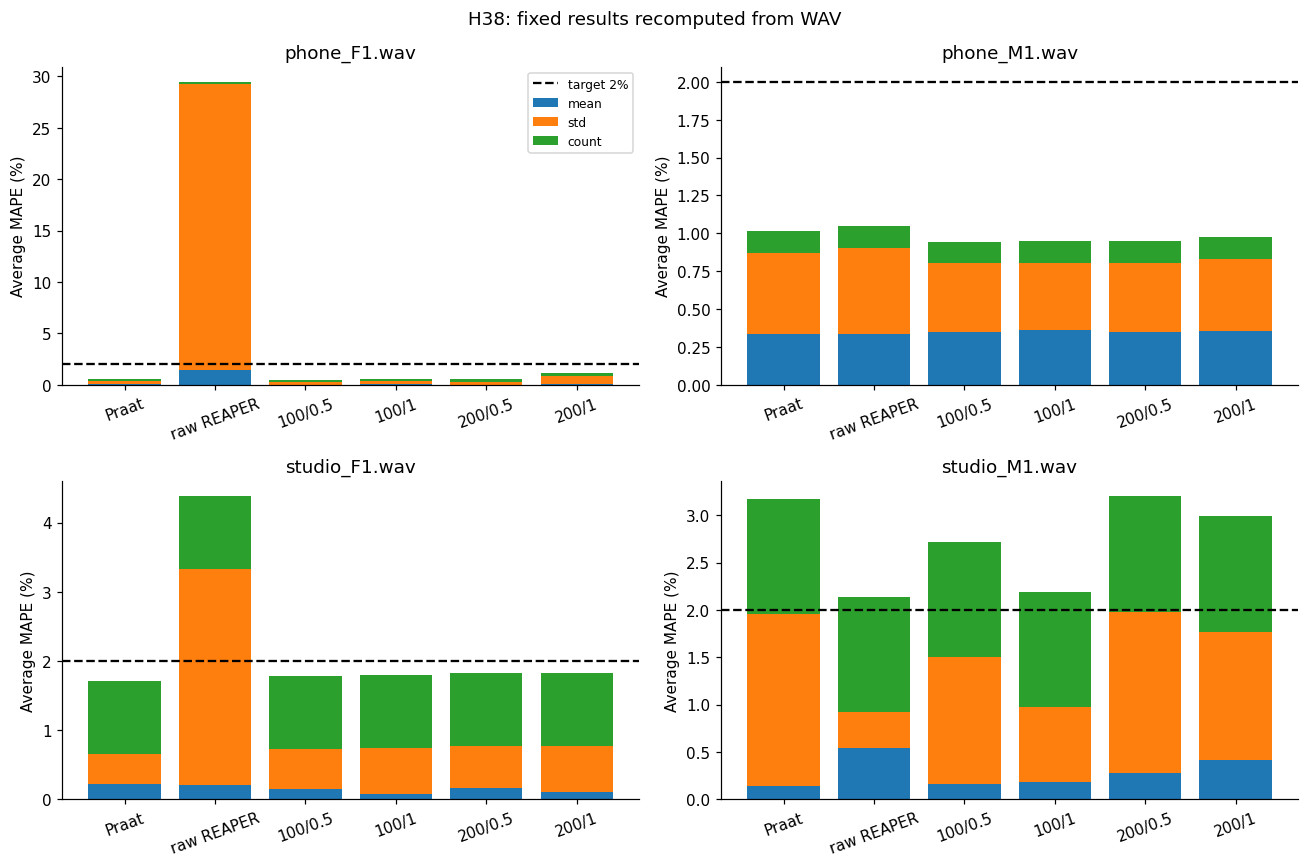

In [4]:
audit.HERE,audit.RESULTS,audit.FIGURES=HERE,HERE/'results',HERE/'figures'
audit.ARTIFACTS.clear()
plot_source=HERE/'results/bounded_notebook_per_file.csv'
for family in families:
    order=[x['id'] for x in registries[family]]
    labels=['Praat','raw REAPER']+[f'{x["agreement_cents"]}/{x["reaper_weight"]:g}' for x in registries[family][2:]]
    fixed=table[(table.evaluation=='fixed')&(table.family==family)]
    fig,axes=audit.plt.subplots(2,2,figsize=(12,8))
    for ax,(file,part) in zip(axes.flat,fixed.groupby('file')):
        part=part.set_index('option_id').loc[order]
        bottom=np.zeros(len(order))
        for metric,label in [('F0mean_mape','mean'),('F0std_mape','std'),('F0num_mape','count')]:
            values=part[metric].to_numpy()/3
            ax.bar(labels,values,bottom=bottom,label=label)
            bottom+=values
        assert np.allclose(bottom,part.average_mape)
        ax.axhline(2,color='black',linestyle='--',label='target 2%')
        ax.set(title=file,ylabel='Average MAPE (%)')
        ax.tick_params(axis='x',rotation=20)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f'{family}: fixed results recomputed from WAV')
    audit.save_figure(f'bounded_notebook_{family}_components',fig,[plot_source],
                      'Các thành phần mean/std/count cộng thành Average MAPE; mọi cấu hình fixed.',
                      'Không chọn best theo held file; LAB chưa có F0 chuẩn từng khung.')
    display(fig)
    audit.plt.close(fig)
for figure in audit.ARTIFACTS:
    figure.update(generator='build_bounded_notebook.py',generator_sha256=audit.digest(HERE/'build_bounded_notebook.py'),command='python research_workbench_2026_10_07/execute_bounded_notebook.py')
audit.json_write(HERE/'results/bounded_notebook_figure_manifest.json',{'figures':audit.ARTIFACTS})
print('Đã xuất PNG/SVG từ các số liệu vừa tính lại; band/alpha ghi trên trục x.')


In [5]:
source_hashes={str(Path(m.__file__).relative_to(REPO)):audit.digest(m.__file__) for m in (dual,reaper,hybrid,core,audit)}
source_hashes.update({key:value for receipt in receipts.values() for key,value in receipt['code_sha256'].items()})
native_calls.update({'hybrid|'+identity+'|'+file:value[2] for (identity,file),value in hybrid.SOURCE_CACHE.items()})
audit.json_write(HERE/'results/bounded_notebook_provenance.json',{
    'source_sha256':source_hashes,'wav_sha256':{x['file']:audit.digest(core.TRAIN/x['file']) for x in items},
    'native_calls':native_calls,'fit_logs':fit_logs,'praat_native_sha256':native_proof['exe_sha256'],
    'sptk_native_sha256':sptk_proof['exe_sha256'],'test_read':False,'new_grid_or_selection':False})
assert len(native_calls)==8 and len(fit_logs)==32
print('PASS32 measured rows: H24control4 + H38fixed24 + nested4.')
print('Control/frozen/notebooks gốc giữ nguyên; mục tiêu đọc từ status và gate đọc từ H38 report.')
print('Native calls/hash/fit exclusions/data/source/projection và contours được lưu để verify độc lập.')


PASS32 measured rows: H24control4 + H38fixed24 + nested4.
Control/frozen/notebooks gốc giữ nguyên; mục tiêu đọc từ status và gate đọc từ H38 report.
Native calls/hash/fit exclusions/data/source/projection và contours được lưu để verify độc lập.


## Nguồn và giới hạn

Đọc H38_REGISTRATION.md, H38_REPORT.md, H37_ERROR_ANALYSIS.md và REAPER_SOURCE_NOTE.md. Source note là README/manual/mã chính thức, không claim fullpaper. Giữ raw hai nguồn và hybrid tags để truy fallback; đây là heuristic engineering hypothesis đã đăng ký, không gán rule cho một paper.

Notebook Python exec/headless display adapter, không Jupyter kernel. Không PDF/test/Drive/deep learning/retry Jev. Notebook gốc và frozen baseline giữ nguyên. Tên F/M chỉ là nhãn nhóm; mỗi ô device×F/M một file, không đủ để coi là quy luật nam/nữ hoặc speaker độc lập.
